In [ ]:
import numpy as np
import pandas as pd
from tensorflow import keras

W = 48
model  = keras.models.load_model(f'best_lstm_w{W}.keras')
X_test = np.load(f'X_test_w{W}.npy')
y_test = np.load(f'y_test_w{W}.npy')


y_pred = model.predict(X_test, verbose=0).flatten()

df = pd.read_csv('merged_cleaned_scaled.csv')
mu, sd = df['AC_POWER'].mean(), df['AC_POWER'].std(ddof=0)

mse  = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse) * sd
mae  = np.mean(np.abs(y_test - y_pred)) * sd
r2   = 1 - mse / np.var(y_test)

print(f"Test samples : {len(y_test)}")
print(f"MSE (scaled) : {mse:.4f}")
print(f"RMSE         : {rmse:.1f} kW")
print(f"MAE          : {mae:.1f} kW")
print(f"R²           : {r2:.3f}")

Test samples : 20460
MSE (scaled) : 0.1753
RMSE         : 159.2 kW
MAE          : 75.3 kW
R²           : 0.774


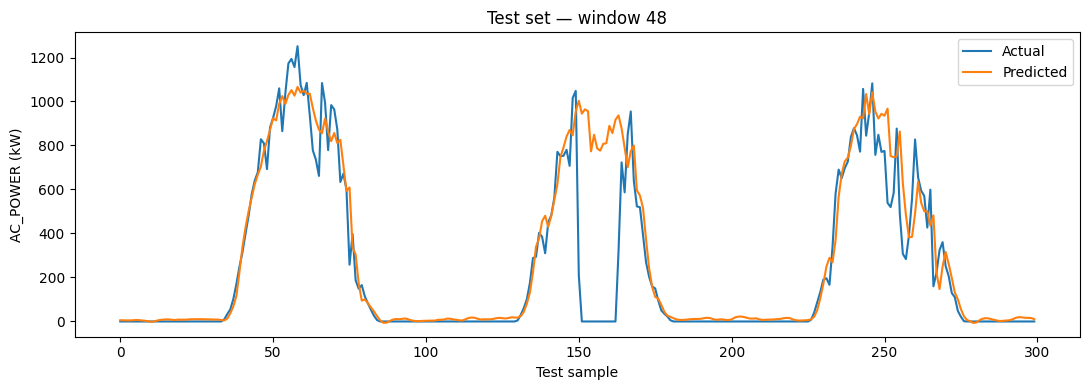

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))
plt.plot(y_test[:300] * sd + mu, label='Actual')
plt.plot(y_pred[:300] * sd + mu, label='Predicted')
plt.ylabel('AC_POWER (kW)'); plt.xlabel('Test sample')
plt.title(f'Test set — window {W}')
plt.legend(); plt.tight_layout(); plt.show()